In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

Cargamos nuesto conjunto de datos desde la liga. Y posteriormente exploramos nuestro conjunto de datos para ver la existencia de NAs y tipos de datos inconsistentes.

In [58]:
df = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/games.csv')

In [59]:
display(df.head())

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [61]:
df.describe(include= "all")

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
count,16713,16715,16446.000000,16713,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000,10014,9949
unique,11559,31,NaN,12,NaN,NaN,NaN,NaN,NaN,96,8
top,Need for Speed: Most Wanted,PS2,NaN,Action,NaN,NaN,NaN,NaN,NaN,tbd,E
freq,12,2161,NaN,3369,NaN,NaN,NaN,NaN,NaN,2424,3990
mean,NaN,NaN,2006.484616,NaN,0.263377,0.145060,0.077617,0.047342,68.967679,NaN,NaN
std,NaN,NaN,5.877050,NaN,0.813604,0.503339,0.308853,0.186731,13.938165,NaN,NaN
min,NaN,NaN,1980.000000,NaN,0.000000,0.000000,0.000000,0.000000,13.000000,NaN,NaN
25%,NaN,NaN,2003.000000,NaN,0.000000,0.000000,0.000000,0.000000,60.000000,NaN,NaN
50%,NaN,NaN,2007.000000,NaN,0.080000,0.020000,0.000000,0.010000,71.000000,NaN,NaN
75%,NaN,NaN,2010.000000,NaN,0.240000,0.110000,0.040000,0.030000,79.000000,NaN,NaN


In [62]:
df.isna().mean().sort_values(ascending=False)

,0
Critic_Score,0.513192
Rating,0.404786
User_Score,0.400897
Year_of_Release,0.016093
Name,0.000120
Genre,0.000120
Platform,0.000000
JP_sales,0.000000
EU_sales,0.000000
NA_sales,0.000000


Los nombres de las columnas del conjunto de datos presentan una combinación de letras mayúsculas y minúsculas, por lo que se estandarizaron convirtiendo todos los caracteres a minúsculas.

Asimismo, se identificaron tipos de datos inconsistentes en las columnas year_of_release y user_score, por lo que se convirtieron a tipo entero (int) y decimal (float), respectivamente. Los valores "TBD" de la columna user_score se transformaron en valores nulos (NA) utilizando el parámetro coerce, ya que no aportan información numérica útil para el análisis, y es necesario contar con valores numéricos para realizar operaciones como agrupaciones, correlaciones y pruebas estadísticas.

Respecto a los valores ausentes en las columnas name y year_of_release, estos fueron imputados/eliminados (según tu proceso) debido a que, sin el nombre del juego y el año de lanzamiento, el resto de la información pierde relevancia analítica.

Por otro lado, se decidió no imputar los valores ausentes en critic_score y user_score, ya que representan evaluaciones reales. Rellenarlos con promedios o medianas podría introducir sesgos en los análisis de correlación y en las pruebas estadísticas.



In [63]:
#Convertimos el nombre de las columnas a minúsculas
new_col = {col :col.lower() for col in df.columns}
df.rename(columns= new_col, inplace = True)

In [64]:
#Eliminamos los NAs de la columna 'name' y en 'year_of_release'
df.dropna(subset = 'name', inplace = True)
df.dropna(subset = 'year_of_release', inplace = True)

#Hacemos conversiones en los tipos de datos de las columnas 'year_of_release' y 'user_score'
df['year_of_release'] = df['year_of_release'].astype('int')
#Convertimos las cadenas 'tbd' de la columna 'user_score' a NAs porque no nos aporta nada.
df["user_score"] = df["user_score"].replace("tbd", np.nan)
df["user_score"] = pd.to_numeric(df["user_score"], errors="coerce", downcast= 'float')

#Rellenamos los datos faltantes de 'rating' para crear la categoría 'unknown':
df["rating"] = df["rating"].fillna("unknown")

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float32
 10  rating           16444 non-null  object 
dtypes: float32(1), float64(5), int64(1), object(4)
memory usage: 1.4+ MB


In [66]:


display(df['user_score'].describe())

,user_score
count,7463.000000
mean,7.126329
std,1.499448
min,0.000000
25%,6.400000
50%,7.500000
75%,8.200000
max,9.700000



# **¿Cuántos juegos fueron lanzados en diferentes años? ¿Son significativos los datos de cada período?**

In [67]:
#Calculamos las ventas totales
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

Número de lanzamientos de juegos por año.

<Axes: title={'center': 'Lanzamientos por año'}, xlabel='Año', ylabel='Lanzamientos'>

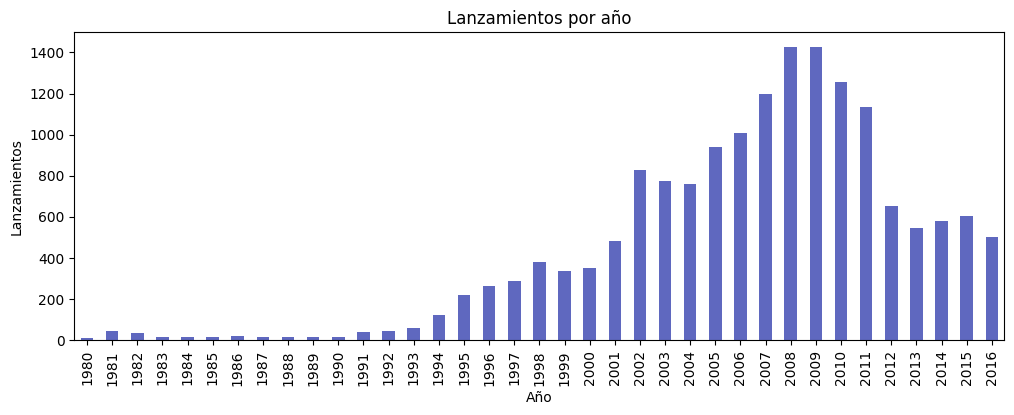

In [68]:
#Agrupamos los datos para calcular el número de lanzamiento de juegos por año.
releases_by_year = df.groupby(by = 'year_of_release')['name'].count()
releases_by_year.plot(kind= 'bar' , xlabel = 'Año', ylabel= 'Lanzamientos', title = 'Lanzamientos por año',figsize=(12,4),  color= '#5F68BF')

Al analizar el número de lanzamientos por año, se observa que a partir de 1994 la industria de los videojuegos experimenta un crecimiento sostenido, alcanzando su punto máximo entre 2008 y 2009. Posteriormente, a partir de 2012, se presenta una disminución notable en el ritmo de lanzamientos, lo que sugiere un cambio en la dinámica del mercado.

<Axes: title={'center': 'Lanzamiento de videojuegos por plataforma'}, xlabel='Plataforma', ylabel='Lanzamientos'>

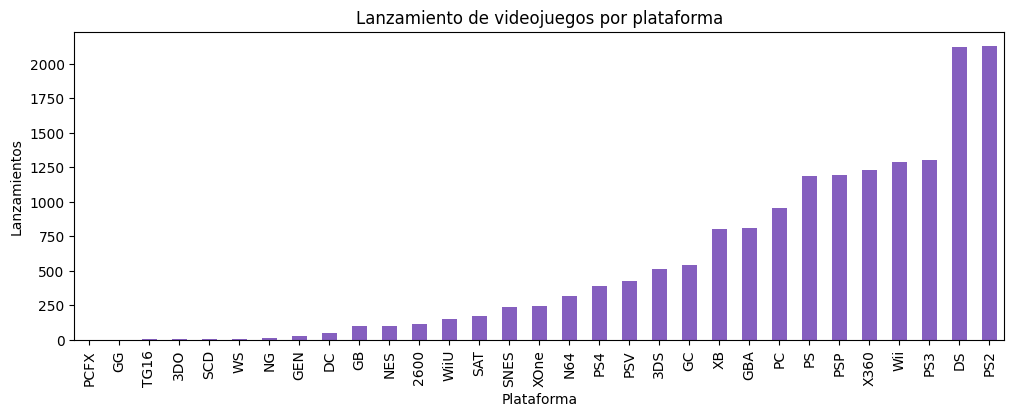

In [69]:
#Calculamos el número de lanzamiento de videojuegos por plataforma.
releses_by_platform = df.groupby(by = 'platform')['name'].count()

releses_by_platform.sort_values(ascending = True).plot(kind = 'bar', xlabel = 'Plataforma', ylabel = 'Lanzamientos',\
                                                       title = 'Lanzamiento de videojuegos por plataforma', figsize=(12,4), color = '#855FBF')

Al agregar los datos por plataforma, se identifica que Nintendo DS y PlayStation 2 son las plataformas con mayor número total de lanzamientos. Este comportamiento es consistente con el periodo de mayor expansión observado en el análisis temporal, ya que ambas plataformas tuvieron una presencia dominante durante los años de mayor producción de videojuegos.

Al enfocarse en las plataformas con mayores ventas totales y analizar la evolución de sus lanzamientos a lo largo del tiempo, se observa que el año 2008 representa el punto máximo en el número de lanzamientos, seguido de una tendencia descendente en los años posteriores. Esta disminución podría estar relacionada con la transición hacia nuevas generaciones de plataformas, así como la priorización de la industria hacia menos títulos.

En conjunto, estos resultados permiten identificar patrones claros en el ciclo de vida de las plataformas y justifican el uso de periodos más recientes para analizar tendencias actuales y realizar proyecciones futuras.

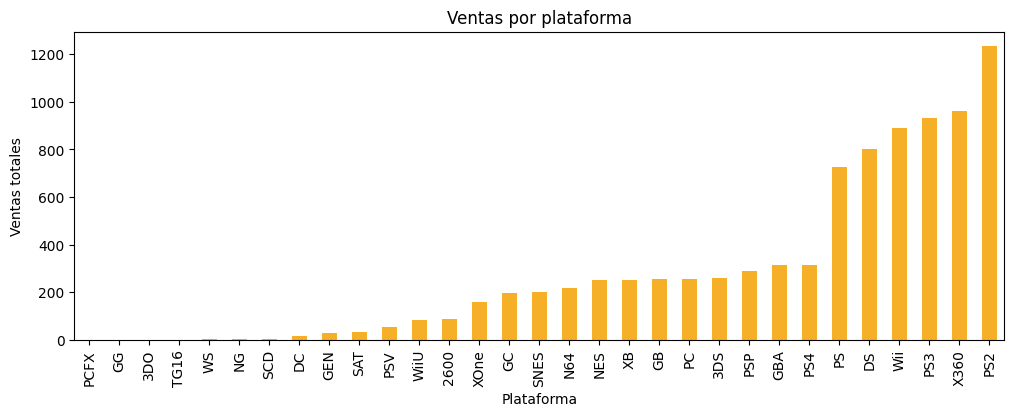

In [70]:
#Calculamos el número de ventas totales por plataforma y seleccionamos el top 5 de ventas
sales_by_platform = df.groupby(by = 'platform')['total_sales'].sum()
sales_by_platform.sort_values(ascending = True).plot(kind = 'bar', xlabel = 'Plataforma', ylabel = 'Ventas totales', \
                                                     title = 'Ventas por plataforma', figsize=(12,4), color= '#F5B027')

top_platforms = list(sales_by_platform.sort_values(ascending = False).index)[:6]

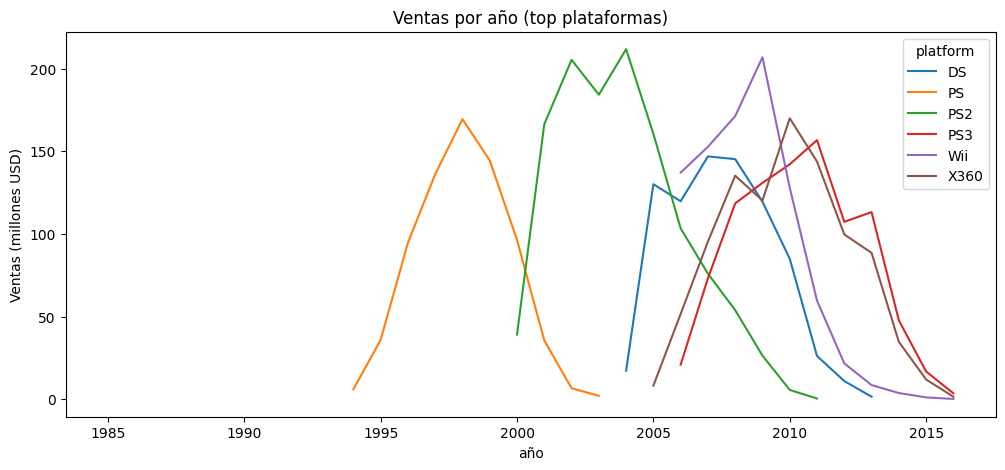

In [71]:
pivot = (df[df["platform"].isin(top_platforms)]
         .pivot_table(index="year_of_release", columns="platform", values="total_sales", aggfunc="sum")
         .sort_index())

pivot.plot(figsize=(12,5), title= "Ventas por año (top plataformas)", xlabel= "año", ylabel= "Ventas (millones USD)")

plt.show()

En la gráfica podemos obervar que las plataformas que tenían muchas ventas en la pasado, pero que actualmente dejaron de vender son: PS, PS2 y DS

In [72]:
span_platform = df[df['platform'].isin(top_platforms)].groupby(by =['platform'])['year_of_release'].min().reset_index()
span_platform.rename(columns = {'year_of_release' : 'min_year'}, inplace =True)
span_platform['max_year'] = df[df['platform'].isin(top_platforms)].groupby(by =['platform'])['year_of_release'].max().reset_index()['year_of_release']

span_platform['years_diff'] = span_platform['max_year'] - span_platform['min_year']

span_platform = span_platform.sort_values(by= ['max_year', 'years_diff'], ascending= True)
display( span_platform)




,platform,min_year,max_year,years_diff
1,PS,1994,2003,9
2,PS2,2000,2011,11
0,DS,1985,2013,28
3,PS3,2006,2016,10
4,Wii,2006,2016,10
5,X360,2005,2016,11


Al analizar las ventas totales por plataforma, se observa que PlayStation 2 (PS2) lidera ampliamente en ventas acumuladas, seguida por Xbox 360, PlayStation 3, Wii y Nintendo DS. Este resultado indica que las plataformas con mayores ventas no necesariamente son aquellas con mayor número de lanzamientos.

Al examinar la evolución de las ventas anuales de las plataformas con mayores ventas totales, se identifica un patrón claro de crecimiento, madurez y declive. En particular, PS2 presenta un rápido crecimiento a inicios de la década de 2000, alcanzando su punto máximo entre 2003 y 2004, seguido de una disminución progresiva. Un comportamiento similar se observa en plataformas como Wii, PS3 y Xbox 360, cuyo pico de ventas se concentra entre 2008 y 2010, periodo que coincide con el auge observado previamente en el número total de lanzamientos.

El análisis del intervalo temporal entre el primer y último año de lanzamiento de juegos para estas plataformas muestra que su ciclo de vida comercial oscila generalmente entre 9 y 11 años, lo que sugiere un patrón relativamente estable en la duración de las generaciones de consolas. Aunque algunas plataformas, como Nintendo DS, presentan un periodo más prolongado, este comportamiento puede atribuirse a su amplia adopción y a la coexistencia con generaciones posteriores.

En conjunto, estos resultados evidencian que el éxito comercial de una plataforma está fuertemente relacionado con su permanencia en el mercado y con su capacidad para sostener ventas significativas durante varios años, lo cual resulta clave para seleccionar periodos relevantes al momento de realizar análisis prospectivos.

In [73]:
antique = ['PS', 'PS2', 'DS' ]
recent = ['Wii', 'PS3', 'X360']

time =  span_platform.loc[(span_platform['platform'].isin(recent))]['max_year'].min() - span_platform.loc[(span_platform['platform'].isin(antique))]['max_year'].max()
year = span_platform.loc[(span_platform['platform'].isin(recent))]['max_year'].min()
display(f'Tardaron {time} años en aparecer las plataformas más recientes, desde que las plataformas antiguas dejaron de vender juegos. En el año {year}')


'Tardaron 3 años en aparecer las plataformas más recientes, desde que las plataformas antiguas dejaron de vender juegos. En el año 2016'

In [74]:
max = span_platform.loc[(span_platform['platform'].isin(antique))]['years_diff'].max()

min = span_platform.loc[(span_platform['platform'].isin(antique))]['years_diff'].min()

display(f'Tardaron entre {min} y {max} años en desaparecer las plataformas más antiguas con más ventas de juegos')

'Tardaron entre 9 y 28 años en desaparecer las plataformas más antiguas con más ventas de juegos'

A partir del análisis de los años mínimos y máximos de lanzamiento de las plataformas con mayores ventas, se observa que existe un intervalo aproximado de 3 años entre el momento en que las plataformas más antiguas dejan de concentrar ventas y la aparición de plataformas más recientes con mayor relevancia comercial. En particular, este punto de transición se ubica alrededor del año 2016, lo que sugiere un solapamiento entre generaciones de consolas.

Asimismo, al analizar la duración del ciclo de vida de las plataformas antiguas con mayores ventas (PS, PS2 y DS), se observa que estas permanecieron activas durante un periodo que oscila entre 9 y 28 años. Sin embargo, el caso de Nintendo DS destaca por presentar una duración significativamente mayor, lo cual puede atribuirse a su alta popularidad y a la coexistencia con generaciones posteriores de consolas.

Cabe señalar que la presencia de un registro correspondiente al año 1985 para la plataforma Nintendo DS no es consistente con su fecha real de lanzamiento, por lo que dicho valor probablemente corresponde a un error en los datos. A pesar de ello, el patrón general indica que las plataformas más exitosas tienden a mantenerse activas durante varios años antes de ser reemplazadas por nuevas generaciones.

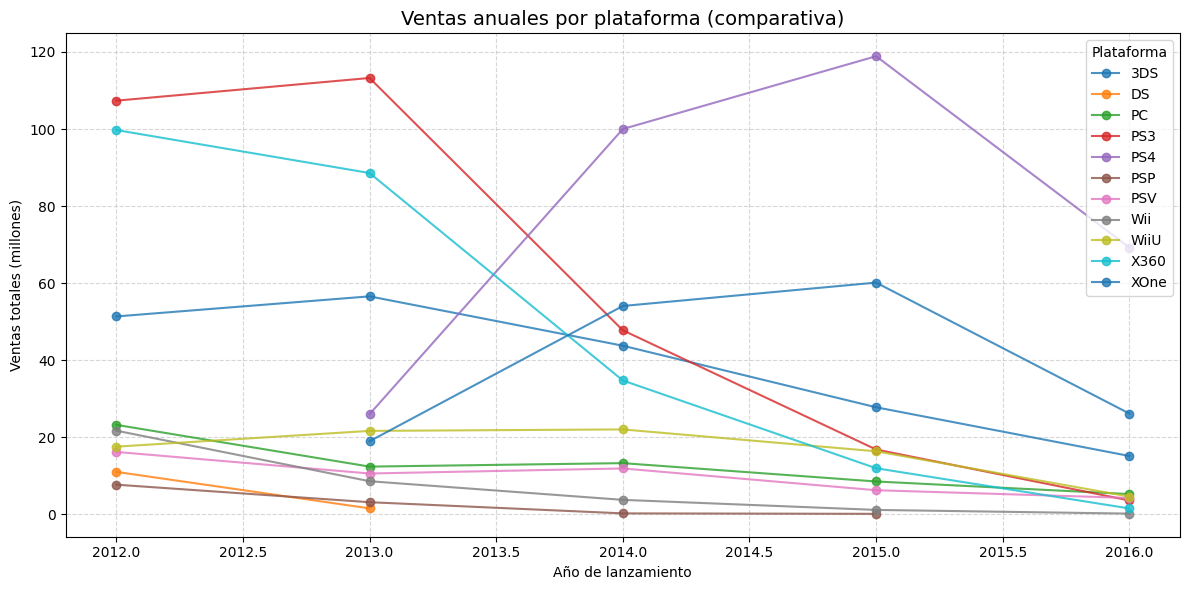

In [75]:
# Agrupar por plataforma y año, sumando ventas
sales_by_platform = df[df['year_of_release']> 2011].groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack()

# Crear gráfica de líneas
sales_by_platform.plot(kind='line', figsize=(12, 6), marker='o', alpha=0.8)

plt.title('Ventas anuales por plataforma (comparativa)', fontsize=14)
plt.xlabel('Año de lanzamiento')
plt.ylabel('Ventas totales (millones)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Plataforma')
plt.tight_layout()
plt.show()

In [76]:
df_recent = df[df['year_of_release'] >= 2013]

Se seleccionaron datos a partir de 2013 debido a que, en ese periodo, las principales plataformas históricas comienzan a perder relevancia comercial y surgen nuevas consolas que dominan el mercado. Este enfoque permite analizar únicamente plataformas vigentes y obtener estimaciones más representativas para el año 2017.

In [77]:
platform_recent_sales = (df_recent.groupby(["year_of_release","platform"])["total_sales"].sum().reset_index())

# ventas totales recientes por plataforma
recent_total = df_recent.groupby("platform")["total_sales"].sum().sort_values(ascending=False)
recent_total.head(10)


,total_sales
platform,
PS4,314.14
PS3,181.43
XOne,159.32
3DS,143.25
X360,136.80
WiiU,64.63
PC,39.43
PSV,32.99
Wii,13.66


In [78]:
trend = (df_recent.pivot_table(index="platform", columns="year_of_release", values="total_sales", aggfunc="sum").fillna(0))

cols = [c for c in trend.columns if c in [2015, 2016]]
trend[cols].sort_values(cols[-1], ascending=False).head(15)


year_of_release,2015,2016
platform,,
PS4,118.90,69.25
XOne,60.14,26.15
3DS,27.78,15.14
PC,8.52,5.25
WiiU,16.35,4.60
PSV,6.25,4.25
PS3,16.82,3.60
X360,11.96,1.52
Wii,1.14,0.18


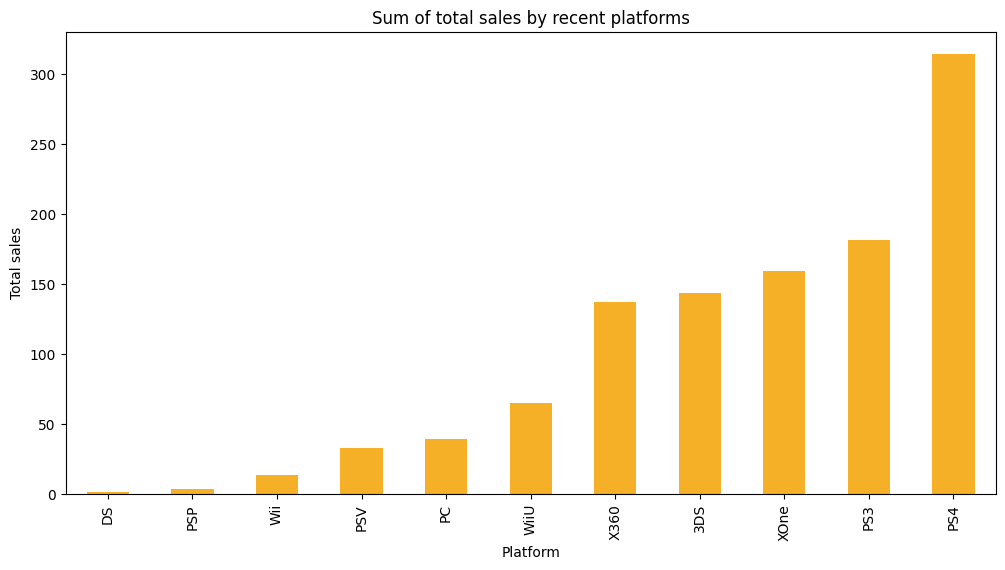

In [79]:
sales_by_platform = df_recent.groupby(by = 'platform')['total_sales'].sum()
sales_by_platform.sort_values(ascending = True).plot(kind = 'bar', xlabel = 'Platform', ylabel = 'Total sales', \
                                                     title = 'Sum of total sales by recent platforms', figsize=(12,6), color= '#F5B027')

top_platforms = list(sales_by_platform.sort_values(ascending = False).index)[:6]

orderered_platforms = list(sales_by_platform.sort_values(ascending = True).index)

Al analizar las ventas totales de las plataformas a partir del año 2013, se observa que PlayStation 4 destaca claramente como la plataforma líder en ventas acumuladas durante el periodo reciente. Le siguen PlayStation 3, Xbox One, Nintendo 3DS y Xbox 360, lo que indica que, aunque algunas plataformas pertenecen a generaciones anteriores, continúan teniendo una presencia relevante en el mercado durante los primeros años del periodo analizado.

En contraste, plataformas como Wii, PSP, PS Vita y Nintendo DS presentan niveles de ventas considerablemente más bajos, lo que sugiere una pérdida de relevancia comercial en comparación con las consolas más recientes.

Estos resultados refuerzan la idea de que el éxito comercial en el periodo reciente se concentra en un número reducido de plataformas dominantes, las cuales resultan más adecuadas para el análisis de tendencias actuales y la planificación de estrategias de mercado orientadas a años posteriores, como 2017.

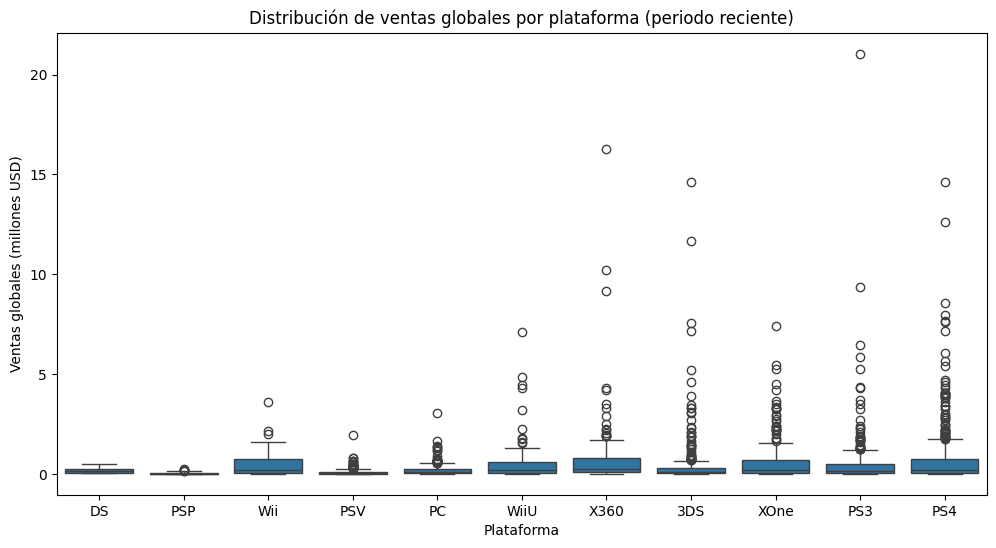

In [80]:
plt.figure(figsize=(12,6))

sns.boxplot(x=df_recent['platform'], y=df_recent['total_sales'], order=orderered_platforms)

plt.title("Distribución de ventas globales por plataforma (periodo reciente)")
plt.xlabel("Plataforma")
plt.ylabel("Ventas globales (millones USD)")

plt.show()

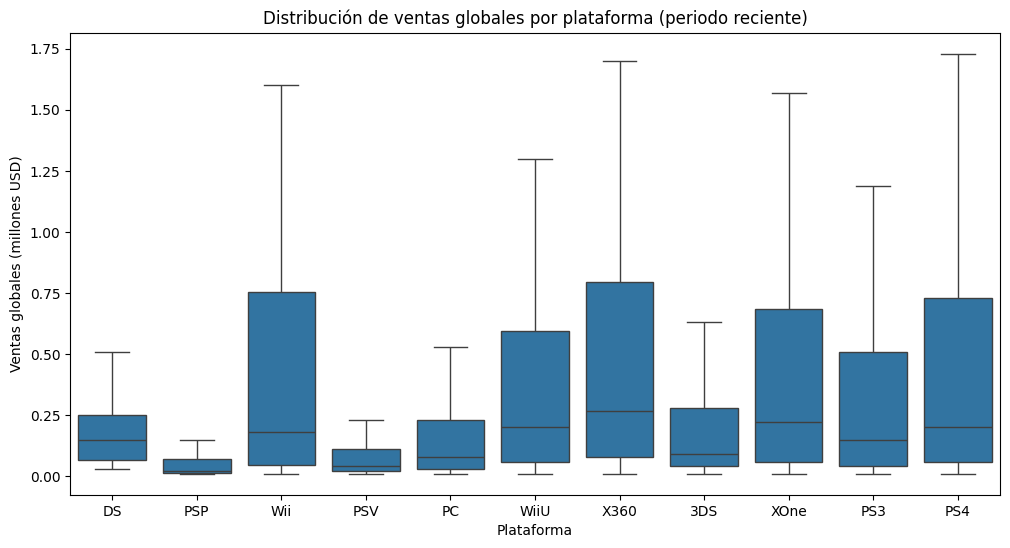

In [81]:
plt.figure(figsize=(12,6))

sns.boxplot(x=df_recent['platform'], y=df_recent['total_sales'], showfliers=False, order=orderered_platforms)

plt.title("Distribución de ventas globales por plataforma (periodo reciente)")
plt.xlabel("Plataforma")
plt.ylabel("Ventas globales (millones USD)")

plt.show()


La gráfica de caja presentada muestra la distribución de ventas totales por plataforma, permitiendo observar diferencias claras entre ellas. Las plataformas PS4, XOne y Wii destacan por tener una mayor dispersión en sus ventas, lo que indica que albergaron tanto títulos con ventas bajas como otros con cifras muy elevadas. En contraste, PSP, PSV y 3DS exhiben rangos más estrechos y medianas más bajas, lo que sugiere un desempeño más modesto en términos de ventas. La mediana de ventas es particularmente alta en plataformas como Wii y PS4, lo cual refleja un mayor éxito comercial promedio. Además, la amplia variabilidad en plataformas como PC indica que, aunque algunos juegos fueron altamente exitosos, muchos otros tuvieron ventas limitadas. Finalmente podemos observar que las plataformas WiiU, X360, 3DS, XOne, PS3 y PS4 tuvieron  algunos lanzamientos bastante exitosos (outliers).


#*¿Cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma (PS4)*

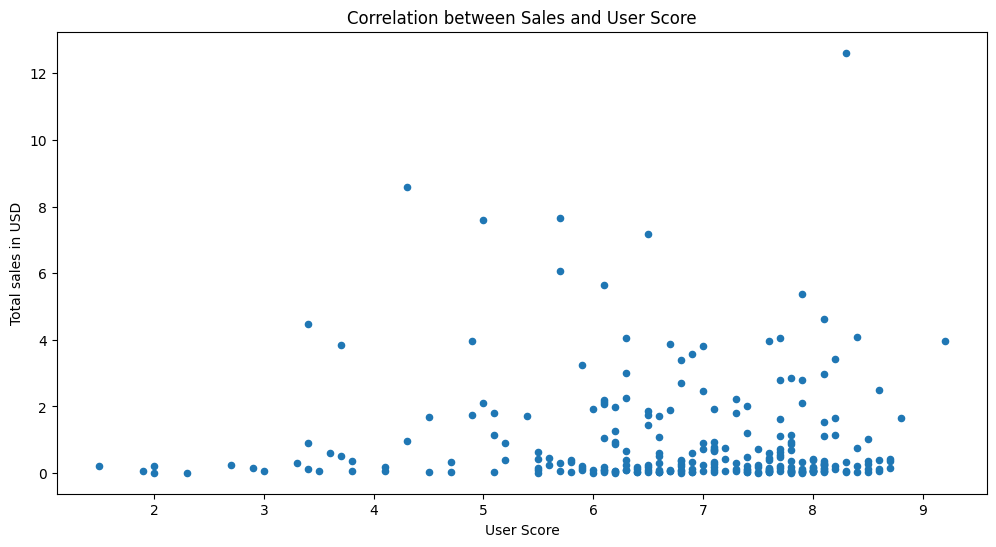

In [82]:
ps4_data = df[df['platform'] == 'PS4'].dropna(subset='user_score')

ps4_data[ps4_data['platform'] == 'PS4'].plot(kind= 'scatter', y='total_sales', x='user_score', xlabel= 'User Score', ylabel = 'Total sales in USD',\
                                             title = 'Correlation between Sales and User Score', figsize=(12, 6))

plt.show()


In [83]:

# Calcular correlación entre ventas totales y calificación de usuario
correlacion = ps4_data[['total_sales', 'user_score']].corr()

print('Coeficiente de correlación:')
print(correlacion['total_sales']['user_score'])


Coeficiente de correlación:
-0.03195710900518881


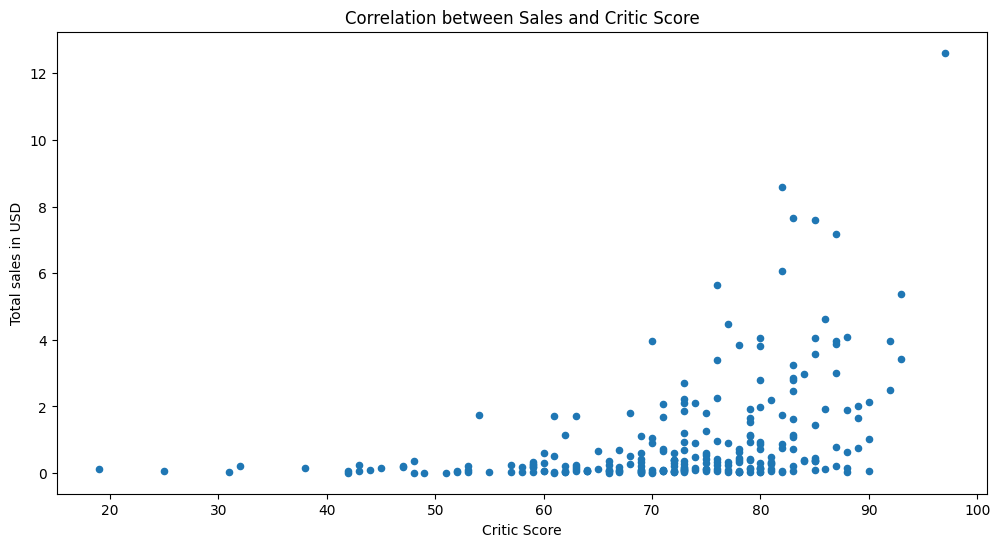

In [84]:
ps4_data.dropna(subset='critic_score', inplace=True)
ps4_data[ps4_data['platform'] == 'PS4'].plot(kind= 'scatter', y='total_sales', x='critic_score',xlabel= 'Critic Score', ylabel = 'Total sales in USD',\
                                             title = 'Correlation between Sales and Critic Score', figsize=(12, 6))
plt.show()




In [85]:
# Calcular correlación entre ventas totales y calificación de usuario
correlacion = ps4_data[['total_sales', 'critic_score']].corr()

print('Coeficiente de correlación:')

print(correlacion['total_sales']['critic_score'])

Coeficiente de correlación:
0.4058948014583664


Para evaluar el impacto de las reseñas en las ventas, se analizó la relación entre las ventas totales y las calificaciones de usuarios y críticos para la plataforma PlayStation 4.

En el caso de la calificación de los usuarios (user_score), el coeficiente de correlación obtenido es cercano a –0.03, lo que indica una ausencia prácticamente total de relación lineal entre la valoración de los usuarios y las ventas de los videojuegos. Esto sugiere que una mayor calificación por parte de los usuarios no se traduce necesariamente en mayores ventas.

Por otro lado, la relación entre las ventas y la calificación de la crítica (critic_score) presenta un coeficiente de correlación cercano a 0.4, lo que indica una correlación positiva débil a moderada. Esto sugiere que los juegos mejor valorados por la crítica tienden a tener mayores ventas, aunque esta relación no es lo suficientemente fuerte como para afirmar que las reseñas de los críticos determinan el éxito comercial de un videojuego.

En conjunto, estos resultados indican que, si bien las reseñas profesionales pueden tener cierta influencia en las ventas, otros factores, como la popularidad de la franquicia, el marketing o la base instalada de la plataforma, juegan un papel más determinante en el desempeño comercial de los videojuegos.

# **Comparación de la venta de los mismos juegos en otras plataformas**

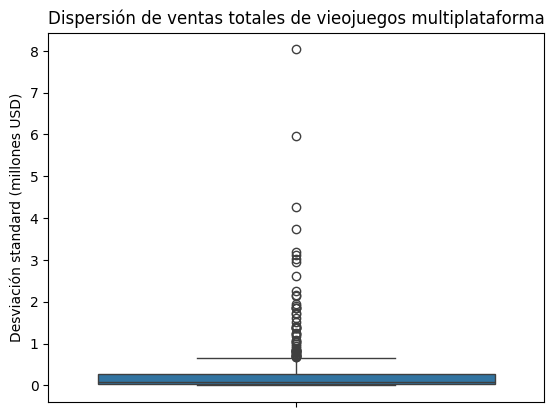

In [86]:
multi = (df_recent.groupby("name")["platform"].nunique())
multi_titles = multi[multi >= 2].index

df_multi = df_recent[df_recent["name"].isin(multi_titles)]
games_multi = df_multi.groupby("platform")["total_sales"].mean().sort_values(ascending=False).head(10)

game_std = df_multi.groupby('name')['total_sales'].std()


sns.boxplot(y= game_std, showfliers=True)
plt.title("Dispersión de ventas totales de vieojuegos multiplataforma")

plt.ylabel("Desviación standard (millones USD)")

plt.show()


In [87]:
display(games_multi)

,total_sales
platform,
PS4,0.884335
X360,0.747111
Wii,0.618636
XOne,0.603080
PS3,0.594621
3DS,0.330484
WiiU,0.321286
PC,0.208231
DS,0.192500


Para analizar cómo varían las ventas de un mismo videojuego entre diferentes plataformas, se seleccionaron aquellos títulos lanzados en dos o más plataformas y se evaluó la dispersión de sus ventas totales mediante la desviación estándar.

El diagrama de caja muestra que aproximadamente el 75 % de los videojuegos multiplataforma presenta una variabilidad relativamente baja en sus ventas, con una desviación estándar inferior a 0.3 millones de USD, lo que indica que, para la mayoría de los títulos, el desempeño comercial es similar entre plataformas. No obstante, se observan outliers con desviaciones significativamente mayores, lo que sugiere que algunos juegos tienen un desempeño comercial muy distinto dependiendo de la plataforma en la que se lanzan.

Al analizar el promedio de ventas de los juegos multiplataforma por plataforma, se observa que PlayStation 4 presenta el mayor valor promedio, seguida por Xbox 360, Wii y Xbox One. Esto indica que, aun tratándose de los mismos títulos, ciertas plataformas tienden a generar mayores ventas, probablemente debido a factores como la calidad de gráficos de cada plataforma.

En conjunto, estos resultados sugieren que, aunque el contenido del juego es el mismo, la plataforma juega un papel relevante en el desempeño comercial, y que PlayStation 4 se posiciona como una de las plataformas más favorables para el lanzamiento de videojuegos multiplataforma durante el periodo analizado.

In [88]:
display(df[df['name'] == 'Call of Duty: Black Ops 3'])

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,unknown,14.63
99,Call of Duty: Black Ops 3,XOne,2015,Shooter,4.59,2.11,0.01,0.68,NaN,NaN,unknown,7.39
1049,Call of Duty: Black Ops 3,X360,2015,Shooter,1.14,0.40,0.00,0.16,NaN,NaN,unknown,1.70
1062,Call of Duty: Black Ops 3,PS3,2015,Shooter,0.49,0.87,0.07,0.26,NaN,NaN,unknown,1.69
6463,Call of Duty: Black Ops 3,PC,2015,Shooter,0.00,0.25,0.00,0.01,NaN,NaN,unknown,0.26


Como ejemplo concreto de la variabilidad en las ventas de un mismo videojuego entre distintas plataformas, se analizó el caso de “Call of Duty: Black Ops 3”, título que fue lanzado en múltiples plataformas durante el mismo año.

Los datos muestran que este juego alcanzó su mayor volumen de ventas en PlayStation 4, con aproximadamente 14.63 millones de USD, seguido por Xbox One con 7.39 millones de USD. En contraste, su desempeño comercial en PC fue considerablemente menor, con apenas 0.26 millones de USD en ventas totales.

# Distribución de ventas por género de videojuegos

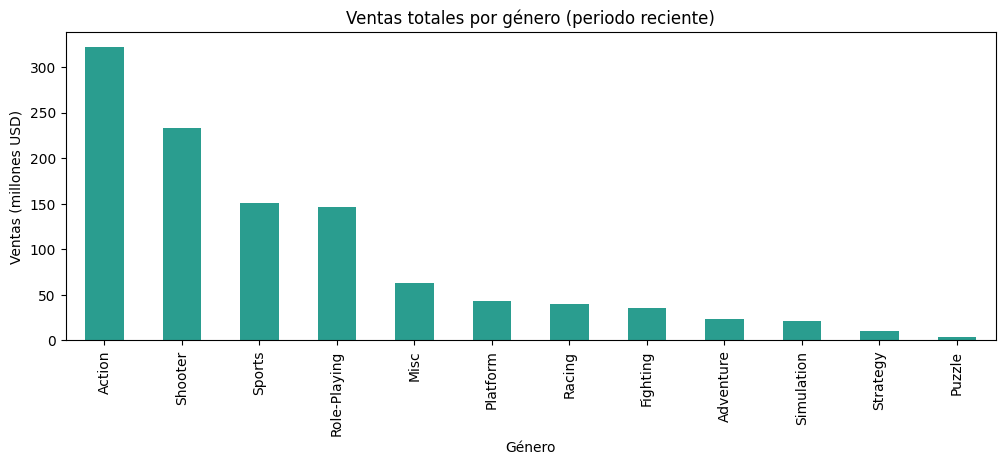

,total_sales
genre,
Action,321.87
Shooter,232.98
Sports,150.65
Role-Playing,145.89
Misc,62.82
Platform,42.63
Racing,39.89
Fighting,35.31
Adventure,23.64


In [89]:
#Agrupamos nuestros datos por género de videojuego y calculamos el total de ventas
genre_sales = df_recent.groupby("genre")["total_sales"].sum().sort_values(ascending=False)
genre_sales.plot(kind="bar", figsize=(12,4), color= '#2A9D8F')
plt.title("Ventas totales por género (periodo reciente)")
plt.xlabel("Género")
plt.ylabel("Ventas (millones USD)")
plt.show()

display(genre_sales)

In [90]:
genre_mean = df_recent.groupby("genre")["total_sales"].mean().sort_values(ascending=False)
display(genre_mean)

,total_sales
genre,
Shooter,1.245882
Sports,0.703972
Platform,0.576081
Role-Playing,0.499623
Racing,0.469294
Fighting,0.441375
Action,0.420196
Misc,0.405290
Simulation,0.350968


/tmp/ipython-input-1131176845.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y= df_recent['total_sales'], x= df_recent['genre'], order = genre_mean.index, palette = colors, legend=False)


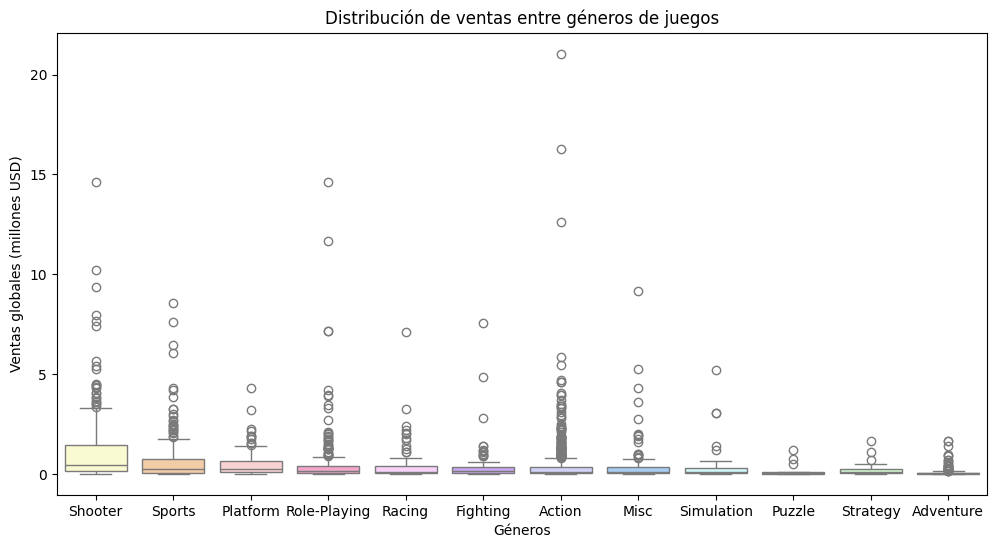

In [91]:
colors = ['#ffffcc','#ffcc99','#ffcccc','#ff99cc','#ffccff','#cc99ff','#ccccff','#99ccff','#ccffff','#99ffcc','#ccffcc','#ccff99']

plt.figure(figsize=(12,6))

sns.boxplot(y= df_recent['total_sales'], x= df_recent['genre'], order = genre_mean.index, palette = colors, legend=False)

plt.title("Distribución de ventas entre géneros de juegos")
plt.xlabel("Géneros")
plt.ylabel("Ventas globales (millones USD)")

plt.show()


Al agrupar los videojuegos por género y analizar sus ventas totales durante el periodo reciente, se observa que el género Action concentra el mayor volumen de ventas acumuladas, seguido por Shooter, Sports y Role-Playing. Este resultado indica que los géneros con mayor número de lanzamientos tienden a dominar las ventas totales del mercado.

Sin embargo, al analizar el promedio de ventas por juego, se identifica un patrón diferente: el género Shooter presenta el mayor promedio de ventas, lo que sugiere que, aunque se lancen menos títulos en comparación con Action, estos tienden a ser comercialmente más exitosos de forma individual.

El diagrama de caja refuerza esta observación, mostrando que el género Action presenta una alta dispersión en las ventas, con algunos títulos extremadamente exitosos (outliers), pero con una mediana relativamente baja. En contraste, el género Shooter muestra una distribución más concentrada y una mediana más alta, lo que indica un desempeño comercial más consistente entre sus lanzamientos.

En conjunto, estos resultados sugieren que, mientras el género Action domina en volumen total gracias a la cantidad de títulos lanzados, el género Shooter destaca por su mayor rentabilidad promedio por juego.

# **Perfil de usuario por región (plataformas, géneros y rating)**

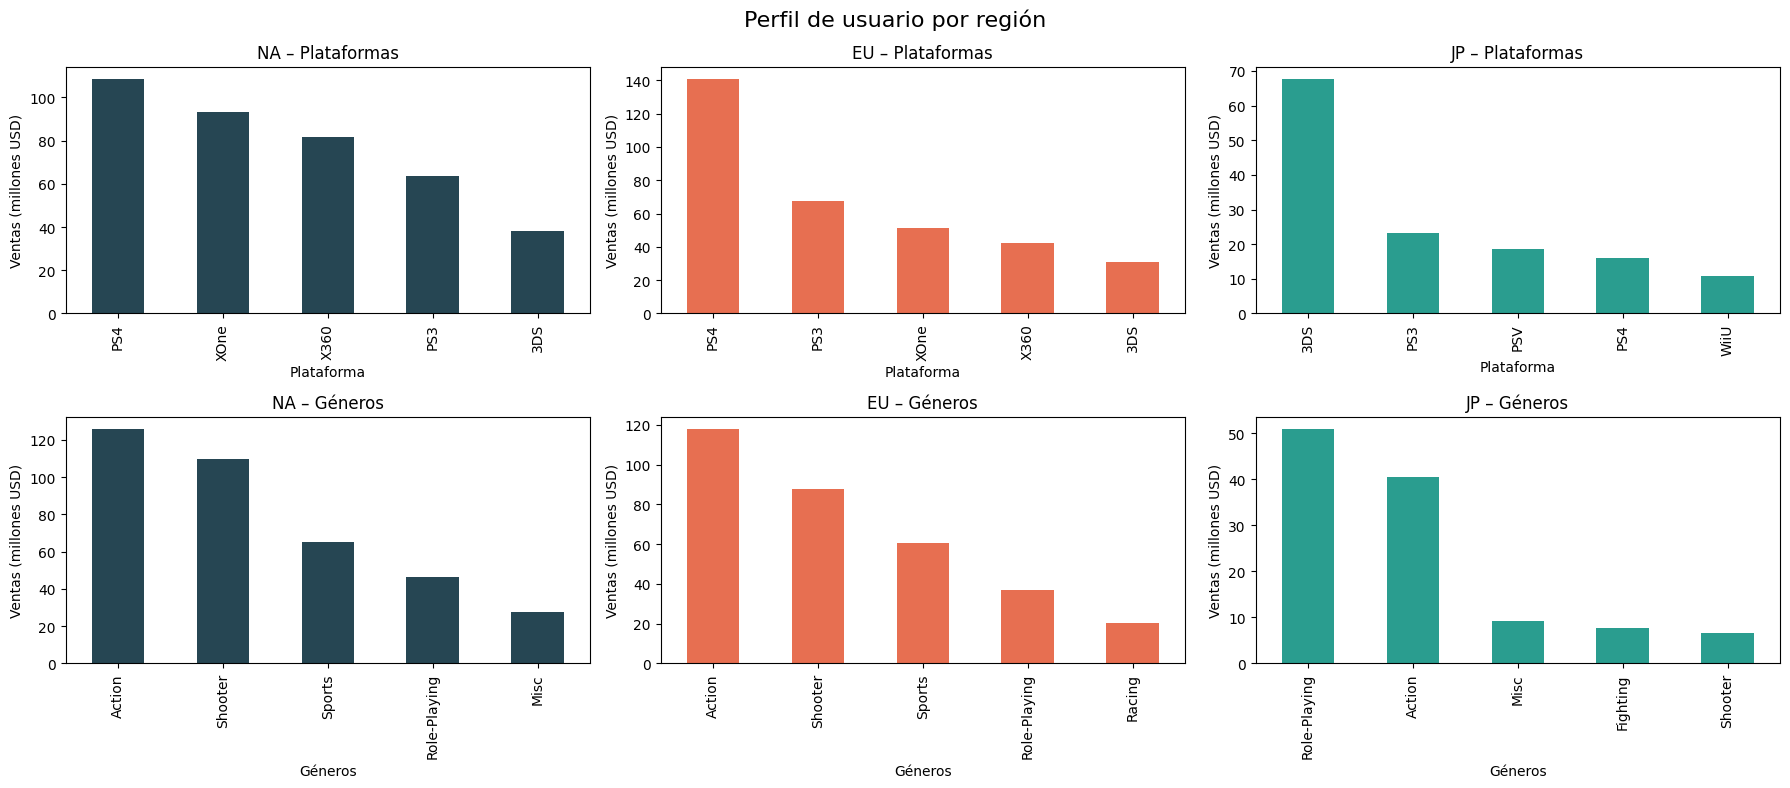

In [92]:
regions = {"NA": "na_sales","EU": "eu_sales","JP": "jp_sales"}

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
region_colors = {"NA": "#264653", "EU": "#E76F51","JP": "#2A9D8F"}

for i, (r, col) in enumerate(regions.items()):
    top_plat = df_recent.groupby("platform")[col].sum().sort_values(ascending=False).head(5)
    top_gen  = df_recent.groupby("genre")[col].sum().sort_values(ascending=False).head(5)

    top_plat.plot(kind="bar", ax=axes[0, i], title=f"{r} – Plataformas", color= region_colors[r])
    axes[0, i].set_ylabel("Ventas (millones USD)")
    axes[0,i].set_xlabel("Plataforma")

    top_gen.plot(kind="bar", ax=axes[1, i], title=f"{r} – Géneros",color= region_colors[r])
    axes[1, i].set_ylabel("Ventas (millones USD)")
    axes[1,i].set_xlabel("Géneros")

plt.suptitle("Perfil de usuario por región", fontsize=16)
plt.tight_layout()
plt.show()


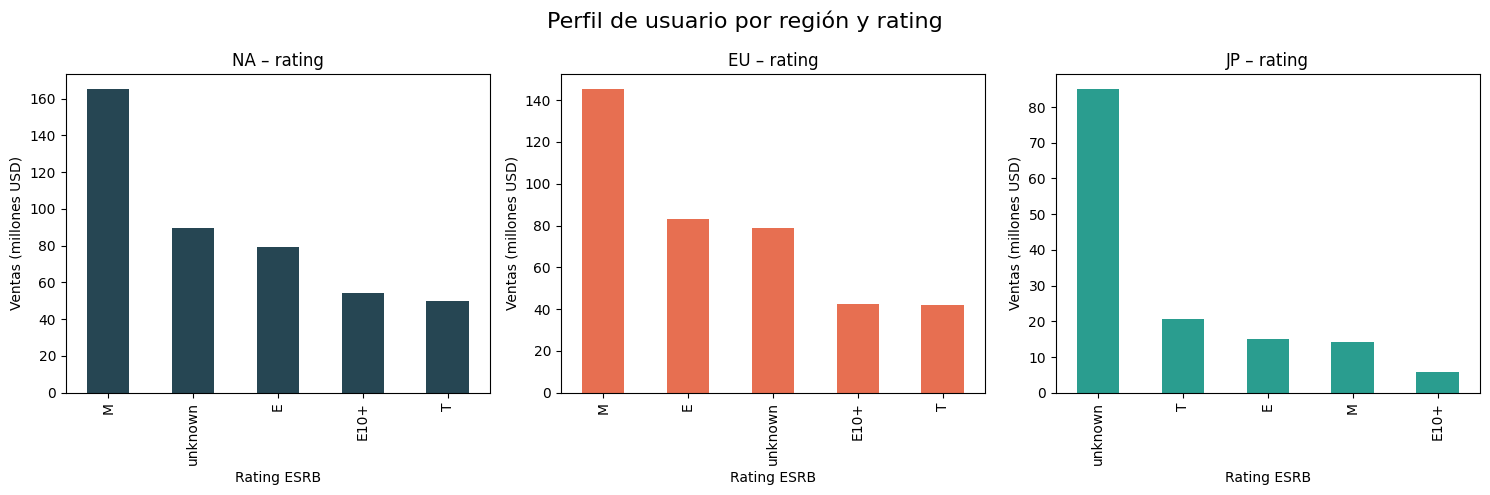

In [93]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for i, (r, col) in enumerate(regions.items()):
    rating_sales = df_recent.groupby("rating")[col].sum().sort_values(ascending=False).head(10)
    # print("\n===", r, "rating top ===")
    # print(rating_sales)
    rating_sales.plot(kind="bar", ax=axes[i], title=f"{r} – rating",color= region_colors[r])
    axes[i].set_ylabel("Ventas (millones USD)")
    axes[i].set_xlabel("Rating ESRB")

plt.suptitle("Perfil de usuario por región y rating", fontsize=16)
plt.tight_layout()
plt.show()


Al segmentar los datos por región (Norteamérica, Europa y Japón), se observan diferencias claras en las preferencias de los consumidores tanto en plataformas como en géneros y clasificaciones ESRB.

En Norteamérica (NA) y Europa (EU) se identifican patrones similares: las ventas se concentran principalmente en plataformas de PlayStation y Xbox, con PS4 como la plataforma dominante en ambas regiones. En cuanto a géneros, Action y Shooter lideran las ventas. Respecto a la clasificación ESRB, los juegos con rating M y E concentran la mayor parte de las ventas, lo que sugiere una amplia aceptación tanto de juegos para adultos como de títulos aptos para audiencias generales.

En contraste, Japón (JP) presenta un perfil de consumo notablemente distinto. En esta región, las ventas se concentran principalmente en plataformas de Nintendo y PlayStation, destacando Nintendo 3DS como la plataforma líder. En términos de género, Role-Playing y Action dominan el mercado japonés, lo que refleja una preferencia por experiencias narrativas y juegos tradicionales del mercado local. Asimismo, la clasificación “unknown” presenta una alta participación en las ventas, lo que indica que tenemos bastantes datos faltantes en el conjunto de datos.

En conjunto, estos resultados muestran que las preferencias de los usuarios varían significativamente según la región y no tanto por la calificación del usuario o el critic score


# Pruebas de hipotesis

Hipótesis nula (H0):  La calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.


Hipótesis alternativa (H1):

La calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes.

Umbral de significancia del valor p: 0.05

In [94]:
alpha = 0.05
xone = df_recent[(df_recent["platform"] == "XOne")]["user_score"].dropna()
pc   = df_recent[(df_recent["platform"] == "PC")]["user_score"].dropna()


stat, pval = stats.ttest_ind(xone, pc, equal_var=False)



In [95]:
if pval < alpha:
    print("Rechazamos Hipotesis nula. La calificación promedio de usuarios para los juegos lanzados en Xbox One y PC son diferentes")
else:
    print("No rechazamos Hipotesis nula. La calificación promedio de usuarios para los juegos lanzados en Xbox One y PC son iguales")

print(f'Ya que obtuvimos un valor p de: {pval}')


No rechazamos Hipotesis nula. La calificación promedio de usuarios para los juegos lanzados en Xbox One y PC son iguales
Ya que obtuvimos un valor p de: 0.147597032047728


Hipótesis nula (H0):  
Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son las mismas.

Hipótesis alternativa (H1):  
Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

Valor alpha: 0.05

In [96]:
action = df_recent[df_recent["genre"] == "Action"]["user_score"].dropna()
sports = df_recent[df_recent["genre"] == "Sports"]["user_score"].dropna()

stat, pval = stats.ttest_ind(action, sports, equal_var=False)


In [97]:
if pval < alpha:
    print("Rechazamos H0. Los promedios de ventas entre juegos de acción y deportes son diferentes.")
else:
    print("No rechazamos H0. Los promedios de ventas entre juegos de acción y deportes son iguales.")

print(f'Ya que obtuvimos un valor p de: {pval}')


Rechazamos H0. Los promedios de ventas entre juegos de acción y deportes son diferentes.
Ya que obtuvimos un valor p de: 1.4459989209941613e-20


Para contrastar las hipótesis se utilizó una prueba t de Student para muestras independientes (ttest_ind), asuminedo que la varianza no es la misma entre las muestras. Esta prueba es adecuada porque:

Se comparan dos grupos independientes (plataformas o géneros distintos).

No se asume igualdad de varianzas entre los grupos, lo cual es una condición más realista para este tipo de datos.

Las calificaciones de los usuarios son variables numéricas continuas.

Se estableció un nivel de significancia α = 0.05, que representa una probabilidad del 5 % de rechazar incorrectamente la hipótesis nula cuando en realidad es verdadera.

El criterio de decisión fue el siguiente:

Si el valor p < α, se rechaza la hipótesis nula.

Si el valor p ≥ α, no se rechaza la hipótesis nula.




En el caso de Xbox One y PC, el valor p obtenido fue mayor que 0.05, por lo que no se rechaza la hipótesis nula. Esto indica que no existen diferencias estadísticamente significativas entre las calificaciones promedio de los usuarios para ambas plataformas. El valor p cercano al 14 % sugiere que las diferencias observadas pueden atribuirse al azar y no a un efecto real entre los grupos.

En el caso de los géneros Acción y Deportes, el valor p obtenido fue menor que 0.05, por lo que se rechaza la hipótesis nula. Esto indica que existen diferencias estadísticamente significativas entre las calificaciones promedio de los usuarios para estos géneros, siendo poco probable que las diferencias observadas se deban al azar.

# **Conclusiones**


En este proyecto se analizó el comportamiento del mercado de videojuegos a partir de datos históricos de ventas, plataformas, géneros, regiones y calificaciones, con el objetivo de identificar patrones que permitan estimar qué factores influyen en el éxito comercial de un videojuego y apoyar la planificación de campañas para el año 2017.

El análisis temporal mostró que la industria experimentó un crecimiento sostenido en el número de lanzamientos desde mediados de la década de 1990, alcanzando su punto máximo alrededor de 2008–2009. Posteriormente, se observó una disminución en el ritmo de lanzamientos, asociada a la transición entre generaciones de consolas. A partir de este comportamiento y del análisis del ciclo de vida de las plataformas, se justificó trabajar con datos posteriores a 2013, enfocándose en plataformas activas y relevantes para el mercado reciente.

Al analizar las ventas por plataforma, se identificó que PlayStation 4 se posiciona como la plataforma dominante en el periodo reciente, seguida por PlayStation 3, Xbox One y Nintendo 3DS. Aunque algunas plataformas pertenecen a generaciones anteriores, su presencia en los primeros años del periodo analizado evidencia un solapamiento generacional común en la industria. El análisis de ventas anuales confirmó este proceso de transición, donde las plataformas antiguas pierden relevancia mientras las nuevas ganan protagonismo.

El estudio de videojuegos multiplataforma mostró que, en la mayoría de los casos, las ventas de un mismo título no varían significativamente entre plataformas; sin embargo, existen excepciones claras donde la plataforma influye de manera determinante en el desempeño comercial. El caso de Call of Duty: Black Ops 3 ilustró esta diferencia, destacando a PS4 como la plataforma más favorable en términos de ventas, lo que refuerza la importancia de la base instalada de usuarios.

Desde la perspectiva de los géneros, se observó que Action concentra las mayores ventas totales debido a la gran cantidad de títulos lanzados, mientras que Shooter presenta el mayor promedio de ventas por juego y una distribución más consistente. Esto sugiere que, aunque el género Action domina en ventas totales, el género Shooter resulta más rentable de forma individual, lo que lo convierte en un género estratégico desde un punto de vista comercial.

El análisis regional reveló diferencias claras en el perfil de consumo. Norteamérica y Europa presentan patrones similares, con preferencia por plataformas de PlayStation y Xbox y por los géneros Action y Shooter. En contraste, Japón muestra una inclinación marcada hacia plataformas de Nintendo y PlayStation, así como una fuerte preferencia por el género Role-Playing, lo que refleja diferencias culturales y de mercado que deben considerarse en cualquier estrategia de lanzamiento.

Finalmente, las pruebas de hipótesis permitieron evaluar la relación entre las calificaciones de los usuarios y distintos grupos. No se encontraron diferencias estadísticamente significativas entre las calificaciones promedio de usuarios en Xbox One y PC, mientras que sí se identificaron diferencias significativas entre los géneros Acción y Deportes. Además, el análisis de correlación mostró que las reseñas de usuarios no tienen una relación clara con las ventas, mientras que las reseñas de la crítica presentan una correlación positiva débil, lo que indica que las calificaciones no son el principal factor que determina el éxito comercial de un videojuego.

En conjunto, los resultados sugieren que el éxito de un videojuego depende de una combinación de factores, entre los que destacan la plataforma, el género, la región y el momento de lanzamiento, mientras que las calificaciones juegan un papel secundario. Estos hallazgos permiten identificar plataformas y géneros prometedores y proporcionan una base sólida para la planificación de estrategias de mercado orientadas al año 2017.